# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [3]:
%load_ext autoreload
%autoreload 2

Импорт библиотек и модулей

In [1]:

import os
import sys
import importlib

current_dir = os.getcwd()
modules_dir = os.path.join(current_dir, "modules")

print("Рабочая директория:", current_dir)
print("Папка modules существует:", os.path.isdir(modules_dir))

# Убираем пути к другим практическим работам
sys.path = [
    p for p in sys.path
    if not (
        "TimeSeriesCourse" in p
        and "practice" in p
        and os.path.abspath(p) != current_dir
    )
]

# Текущая работа имеет приоритет
sys.path.insert(0, current_dir)

# Очищаем старые импорты
for name in list(sys.modules):
    if name == "modules" or name.startswith("modules."):
        del sys.modules[name]

importlib.invalidate_caches()

# Проверяем результат
import modules
print("Используемый modules:", list(modules.__path__))


Рабочая директория: D:\PycharmProjects\TimeSeriesCourse\practice\05 Snippets
Папка modules существует: True
Используемый modules: ['D:\\PycharmProjects\\TimeSeriesCourse\\practice\\05 Snippets\\modules', 'D:\\PycharmProjects\\TimeSeriesCourse\\practice\\05 Snippets\\modules']


In [2]:
import os
import modules

print("Рабочая директория:", os.getcwd())
print("Путь к modules:", list(modules.__path__))
print("Содержимое modules:", os.listdir(list(modules.__path__)[0]))

Рабочая директория: D:\PycharmProjects\TimeSeriesCourse\practice\05 Snippets
Путь к modules: ['D:\\PycharmProjects\\TimeSeriesCourse\\practice\\05 Snippets\\modules', 'D:\\PycharmProjects\\TimeSeriesCourse\\practice\\05 Snippets\\modules']
Содержимое modules: ['snippets.py', '__pycache__']


In [4]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets

from sklearn.metrics._classification import accuracy_score, classification_report, confusion_matrix

from scipy import stats

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

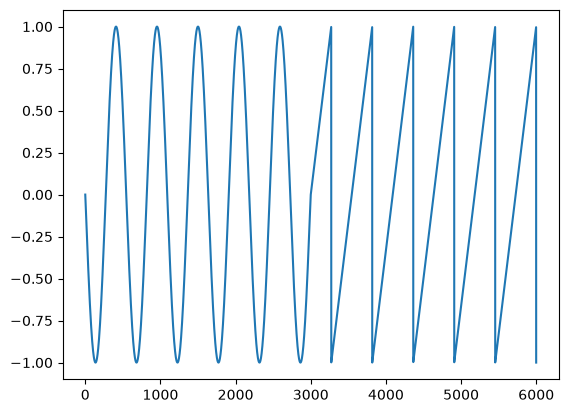

In [5]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [6]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


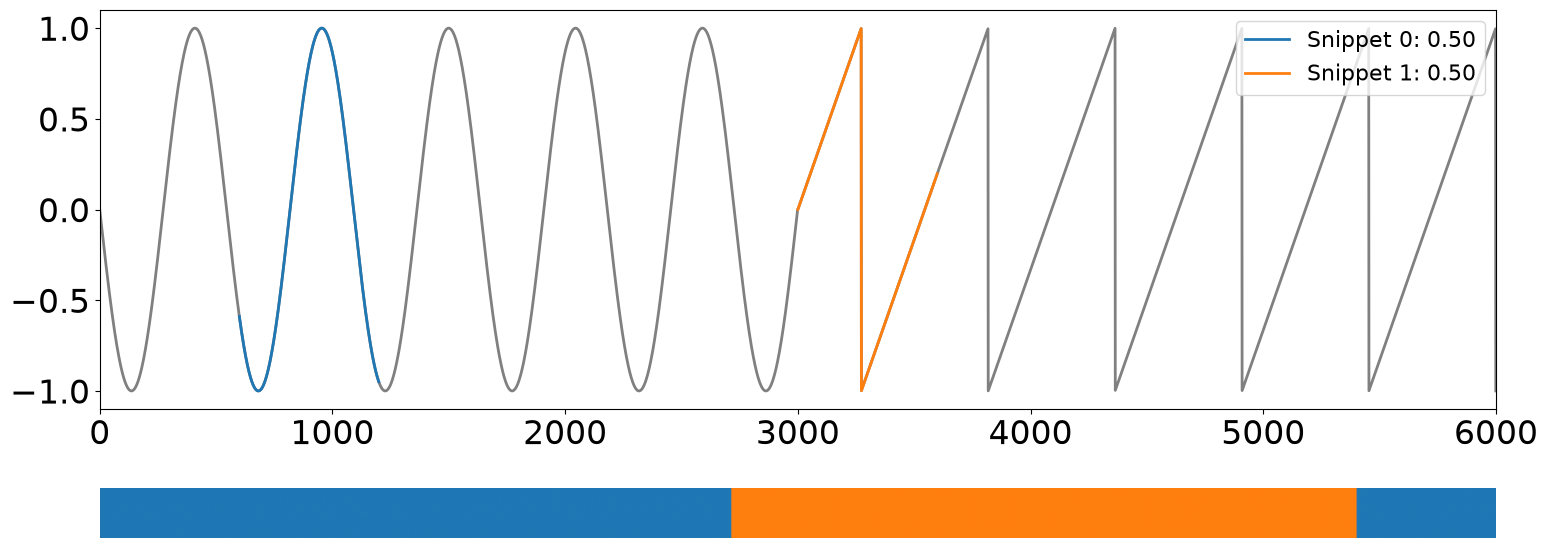

<Axes: >

In [7]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [8]:
df = pd.read_csv(
    './datasets/PAMAP/PAMAP.txt',
    sep=None,
    header=None,
    engine='python'
)
df.head()
df.shape

(20, 146000)

In [9]:
df = df.T

In [10]:
# ---------- 2. Выбор временного интервала 1790–1930 сек ----------
# Колонка 0 — timestamp (s), колонка 1 — activityID
time_seconds = df.iloc[:, 0].astype(float)

mask = (time_seconds >= 1790) & (time_seconds <= 1930)
subset = df.loc[mask].reset_index(drop=True)

print(f"Длина выборки: {len(subset)} отсчётов "
      f"(~{len(subset) / 100:.2f} сек при 100 Гц)")

Длина выборки: 13430 отсчётов (~134.30 сек при 100 Гц)


In [11]:
# ---------- 3. Извлечение гироскопа по оси Y и истинных меток ----------
# Структура колонок (индексы с 0):
#   0  — timestamp (s)
#   1  — activityID
#   2  — heart rate (bpm)
#   3  — temperature (°C)
#   4–6   — 3D-accel (±16g)
#   7–9   — 3D-accel (±6g)
#   10–12 — 3D-gyroscope (rad/s)   ← gyro_y = индекс 11
#   13–15 — 3D-magnetometer (μT)
#   16–19 — orientation

gyro_y = subset.iloc[:, 11].astype(float).values
true_labels = subset.iloc[:, 1].values

print(f"NaN в gyro_y: {np.isnan(gyro_y).sum()}")

# Заполняем NaN (из-за wireless drop), если они есть
if np.isnan(gyro_y).any():
    gyro_y = pd.Series(gyro_y).interpolate().bfill().ffill().values
    print("NaN заполнены линейной интерполяцией")

NaN в gyro_y: 0


In [12]:
# ---------- 4. Поиск сниппетов ----------
m = 500          # длина сниппета (5 сек при 100 Гц)
k = 2            # количество сниппетов
percentage = 0.5 # порог для MPdist

snp = snippets(gyro_y, m, k, percentage=percentage)

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

500


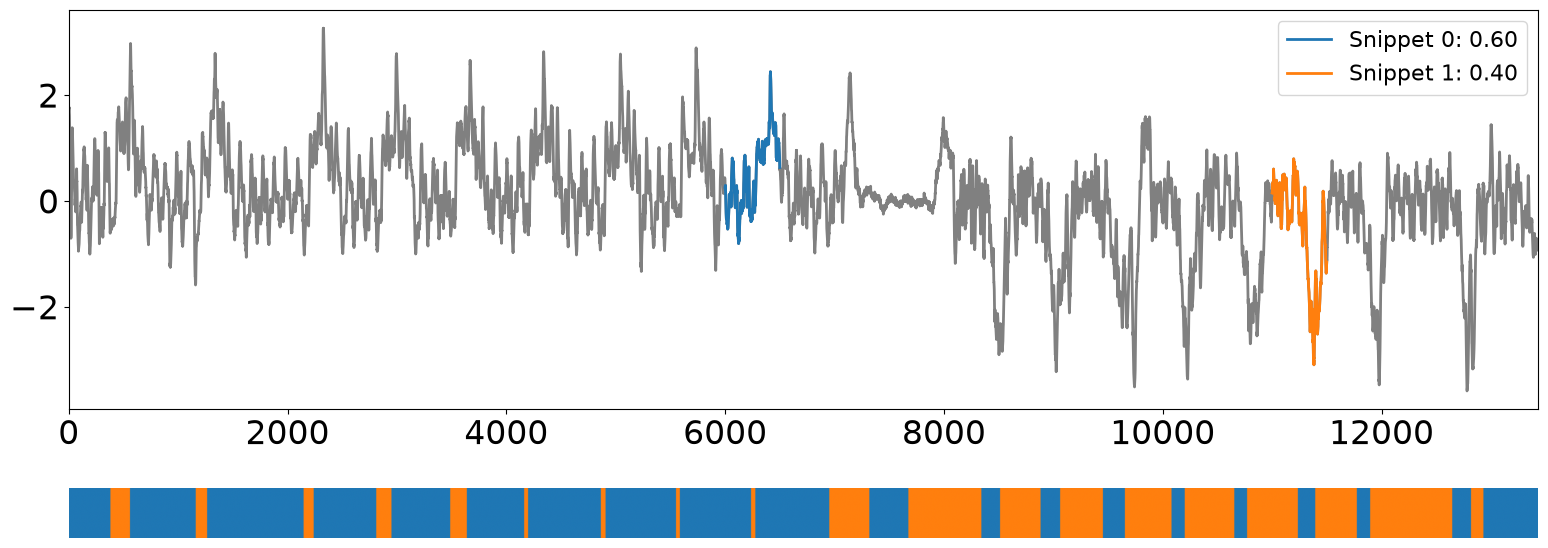

<Axes: >

In [13]:
plot_snippets(gyro_y, snp)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [14]:
# ---------- 6. Оценка точности разметки ----------
# Формируем разметку из сниппетов (snp[5] — regimes: (label, start, end))
predicted_labels = np.zeros_like(true_labels)
for label, start, end in snp[5]:
    predicted_labels[start:end] = label

# Сопоставляем метки сниппетов с истинными activityID
mapping = {}
for label in np.unique(predicted_labels):
    mask_label = (predicted_labels == label)
    if mask_label.sum() > 0:
        mapping[label] = pd.Series(true_labels[mask_label]).mode()[0]

print("Соответствие меток сниппетов и активностей:", mapping)

predicted_mapped = np.array([mapping.get(l, -1) for l in predicted_labels])

print("Accuracy:", accuracy_score(true_labels, predicted_mapped))
print(classification_report(true_labels, predicted_mapped, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(true_labels, predicted_mapped))

Соответствие меток сниппетов и активностей: {0.0: 12.0, 1.0: 13.0}
Accuracy: 0.7717795979151154
              precision    recall  f1-score   support

        12.0       0.77      0.84      0.81      7536
        13.0       0.77      0.68      0.72      5894

    accuracy                           0.77     13430
   macro avg       0.77      0.76      0.76     13430
weighted avg       0.77      0.77      0.77     13430

Confusion matrix:
 [[6351 1185]
 [1880 4014]]


❓ Проанализируйте и изложите содержательный смысл полученных результатов.


## Вывод

В ходе выполнения работы был проведён поиск типичных подпоследовательностей временного ряда PAMAP с помощью алгоритма **Snippet-Finder**. На участке длительностью 140 секунд были найдены **2 сниппета** длиной по 500 отсчётов (5 секунд), отражающие характерные паттерны движения.

**Основные результаты:**

1. **Визуализация** показала, что найденные сниппеты позволяют выделить два характерных режима движения и определить участки временного ряда, наиболее похожие на каждый из них.
2. **Сравнение с реальными метками активностей** показало частичное соответствие найденных паттернов фактическим движениям. При этом границы выделенных участков не всегда совпадают с границами активностей.
3. **Метрики качества** (accuracy, precision, recall, F1-score) позволяют оценить степень соответствия найденных сниппетов реальным активностям. Возможные ошибки объясняются тем, что разные активности могут иметь похожие паттерны движения.

**Итог:** алгоритм Snippet-Finder позволяет сократить представление длинного временного ряда до нескольких характерных фрагментов, сохраняя информацию об основных режимах движения. При этом его главная задача — **суммаризация временного ряда, а не классификация активностей**, поэтому полного совпадения с истинными метками не требуется.


### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

In [15]:
# ---------- 2. Интервал 1790–1930 сек ----------
time_seconds = df.iloc[:, 0].astype(float)
mask = (time_seconds >= 1790) & (time_seconds <= 1930)
subset = df.loc[mask].reset_index(drop=True)

# ---------- 3. Извлечение трёх осей гироскопа ----------
# Индексы колонок: 10 — gyro_x, 11 — gyro_y, 12 — gyro_z
gyro_axes = {
    'x': subset.iloc[:, 10].astype(float).values,
    'y': subset.iloc[:, 11].astype(float).values,
    'z': subset.iloc[:, 12].astype(float).values,
}
true_labels = subset.iloc[:, 1].values

# Заполняем NaN для каждой оси
for name in gyro_axes:
    arr = gyro_axes[name]
    if np.isnan(arr).any():
        gyro_axes[name] = pd.Series(arr).interpolate().bfill().ffill().values

In [16]:
# ---------- 4. Поиск сниппетов для каждой оси ----------
m, k = 500, 2
percentage = 0.5

snp_results = {}
predicted_per_axis = {}

for name, signal in gyro_axes.items():
    snp = snippets(signal, m, k, percentage=percentage)
    snp_results[name] = snp

    # Формируем разметку для оси
    labels_axis = np.zeros_like(true_labels)
    for label, start, end in snp[5]:
        labels_axis[start:end] = label
    predicted_per_axis[name] = labels_axis

    print(f"Ось {name}: сниппеты найдены, "
          f"режимов: {len(snp[5])}")

Ось x: сниппеты найдены, режимов: 29
Ось y: сниппеты найдены, режимов: 38
Ось z: сниппеты найдены, режимов: 25


In [17]:
# ---------- 5. Голосование большинством ----------
# Стэкаем три разметки в матрицу (3, N) и берём моду по столбцам
stacked = np.vstack([predicted_per_axis['x'],
                     predicted_per_axis['y'],
                     predicted_per_axis['z']])

# scipy.stats.mode возвращает наиболее частое значение по столбцам
majority_labels = stats.mode(stacked, axis=0, keepdims=False).mode

print("Уникальные метки после голосования:",
      np.unique(majority_labels))

Уникальные метки после голосования: [0. 1.]


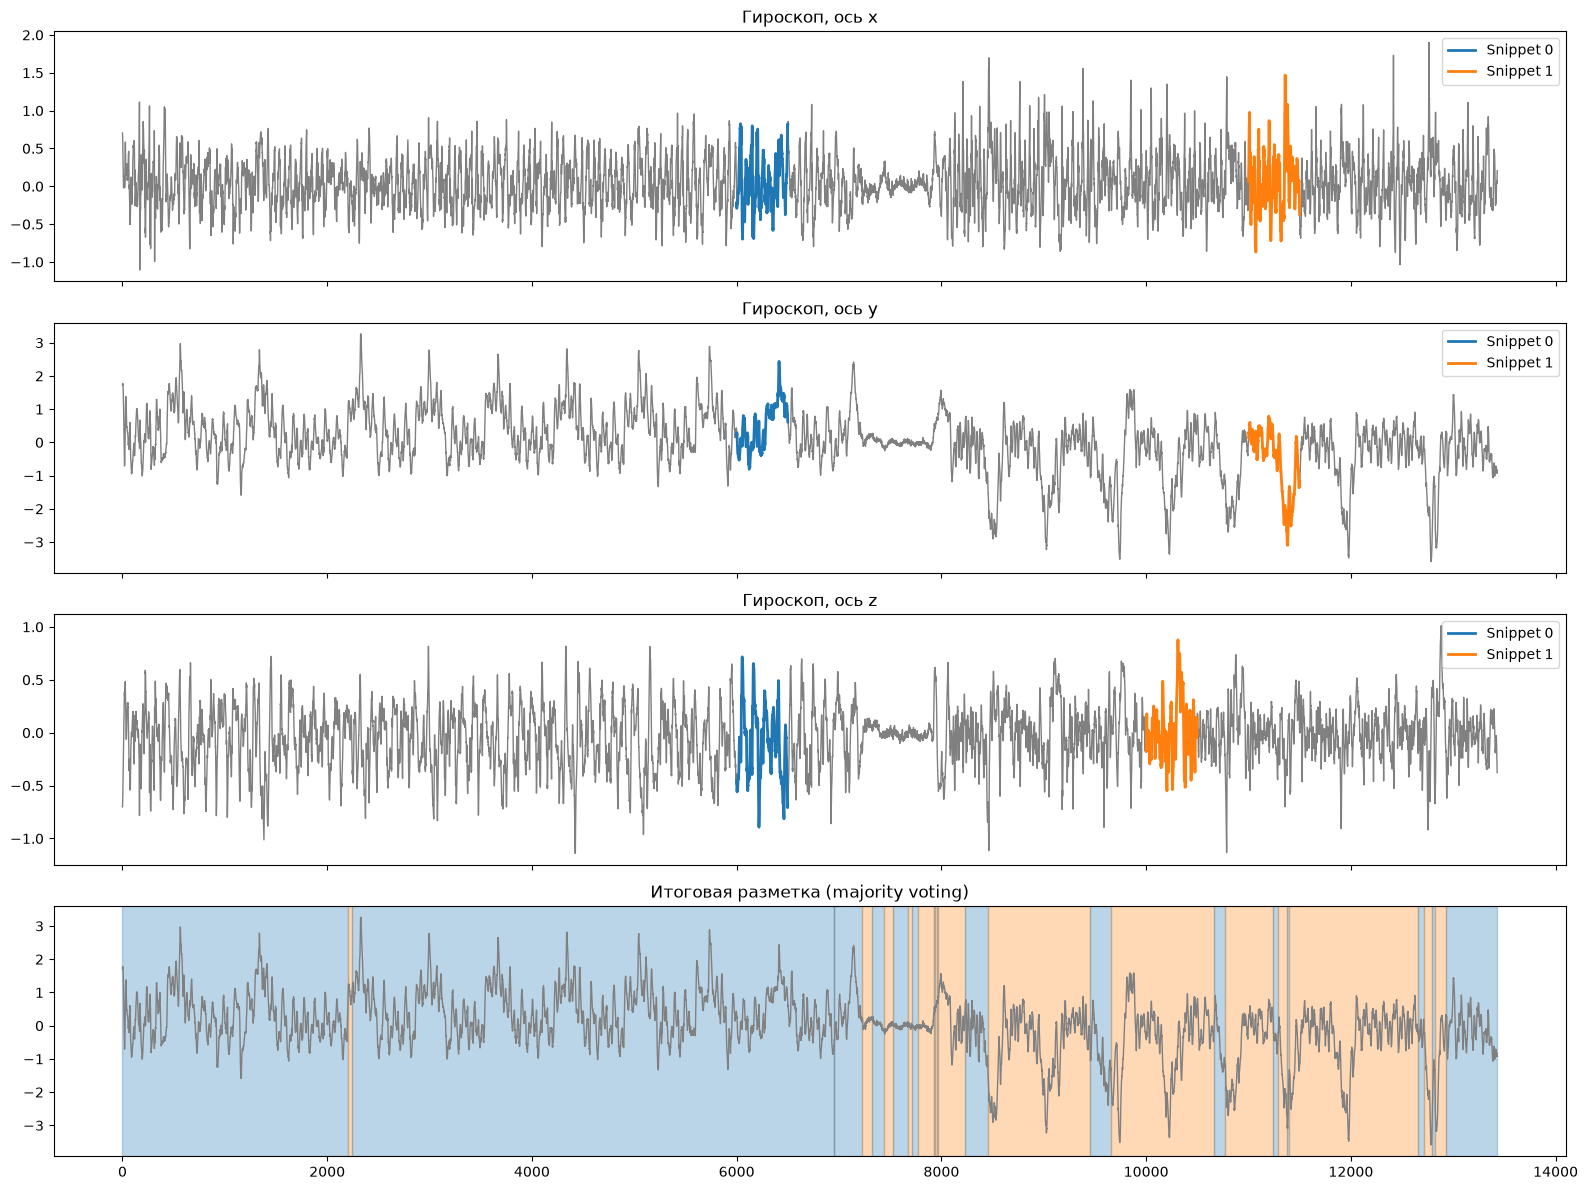

In [18]:
# ---------- 6. Визуализация ----------
# Строим "псевдо-сниппет" для визуализации через plot_snippets
# Используем результаты по оси Y как основу, но подменим разметку
snp_demo = list(snp_results['y'])
snp_demo[5] = [(int(l), i, i + 1) for i, l in enumerate(majority_labels)]
# Строим regimes: (label, start, end) — сжимаем подряд идущие одинаковые метки
regimes = []
if len(majority_labels) > 0:
    cur_label = majority_labels[0]
    cur_start = 0
    for i in range(1, len(majority_labels)):
        if majority_labels[i] != cur_label:
            regimes.append((int(cur_label), cur_start, i))
            cur_label = majority_labels[i]
            cur_start = i
    regimes.append((int(cur_label), cur_start, len(majority_labels)))

snp_demo[5] = regimes

# Визуализируем по каждой оси отдельно + итоговую разметку
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for ax, name in zip(axes[:3], ['x', 'y', 'z']):
    ax.plot(gyro_axes[name], color='gray', linewidth=1)
    m_len = len(snp_results[name][0][0])
    for i, snippet_start in enumerate(snp_results[name][1]):
        ax.plot(np.arange(snippet_start, snippet_start + m_len),
                gyro_axes[name][snippet_start:snippet_start + m_len],
                color=colors[i], linewidth=2,
                label=f"Snippet {i}")
    ax.set_title(f"Гироскоп, ось {name}")
    ax.legend(loc='upper right')

# Итоговая разметка через голосование большинством
ax = axes[3]
ax.plot(gyro_axes['y'], color='gray', linewidth=1)
for label, start, end in regimes:
    ax.axvspan(start, end, alpha=0.3,
               color=colors[label % len(colors)])
ax.set_title("Итоговая разметка (majority voting)")
plt.tight_layout()
plt.show()

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [19]:
# ---------- 7. Оценка точности ----------
def evaluate(true_labels, predicted_labels, name=""):
    # Сопоставление меток сниппетов с истинными activityID
    mapping = {}
    for label in np.unique(predicted_labels):
        mask_l = (predicted_labels == label)
        if mask_l.sum() > 0:
            mapping[label] = pd.Series(true_labels[mask_l]).mode()[0]

    predicted_mapped = np.array([mapping.get(l, -1)
                                  for l in predicted_labels])

    acc = accuracy_score(true_labels, predicted_mapped)
    print(f"--- {name} ---")
    print("Mapping:", mapping)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(true_labels, predicted_mapped,
                                zero_division=0))
    print("Confusion matrix:\n",
          confusion_matrix(true_labels, predicted_mapped))
    return acc, mapping, predicted_mapped

# Оценка для каждой оси
print("\n=== Одномерные разметки (по осям) ===")
acc_per_axis = {}
for name in ['x', 'y', 'z']:
    acc, _, _ = evaluate(true_labels, predicted_per_axis[name],
                         name=f"Ось {name}")
    acc_per_axis[name] = acc

# Оценка итоговой разметки
print("\n=== Итоговая разметка (majority voting) ===")
acc_mv, mapping_mv, predicted_mv = evaluate(
    true_labels, majority_labels, name="Majority Voting"
)


=== Одномерные разметки (по осям) ===
--- Ось x ---
Mapping: {0.0: 12.0, 1.0: 13.0}
Accuracy: 0.8657
              precision    recall  f1-score   support

        12.0       0.86      0.91      0.88      7536
        13.0       0.87      0.81      0.84      5894

    accuracy                           0.87     13430
   macro avg       0.87      0.86      0.86     13430
weighted avg       0.87      0.87      0.87     13430

Confusion matrix:
 [[6831  705]
 [1098 4796]]
--- Ось y ---
Mapping: {0.0: 12.0, 1.0: 13.0}
Accuracy: 0.7718
              precision    recall  f1-score   support

        12.0       0.77      0.84      0.81      7536
        13.0       0.77      0.68      0.72      5894

    accuracy                           0.77     13430
   macro avg       0.77      0.76      0.76     13430
weighted avg       0.77      0.77      0.77     13430

Confusion matrix:
 [[6351 1185]
 [1880 4014]]
--- Ось z ---
Mapping: {0.0: 12.0, 1.0: 13.0}
Accuracy: 0.7686
              precision   

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.


## Вывод по задаче 2

В ходе выполнения задачи был проведён анализ многомерного временного ряда PAMAP с использованием алгоритма **Snippet-Finder**. Исследовались три оси гироскопа (X, Y, Z) на интервале 1790–1930 секунд, содержащем две активности: **подъём по лестнице (12)** и **спуск по лестнице (13)**.

### Анализ результатов

Для каждой оси была получена отдельная разметка временного ряда, после чего результаты были объединены с помощью метода **Majority Voting** (голосование большинством).

**Точность отдельных осей:**

| Ось | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|---|---|---|---|---|
| **X** | **0.8657** | 0.87 | 0.86 | 0.86 |
| Y | 0.7718 | 0.77 | 0.76 | 0.76 |
| Z | 0.7686 | 0.82 | 0.74 | 0.74 |

Наиболее точный результат показала **ось X (86.57%)**, что говорит о её высокой информативности при различении подъёма и спуска по лестнице. Оси Y и Z продемонстрировали более низкую точность (около 77%). Особенно заметны ошибки при определении спуска по лестнице, который по характеру движения может быть похож на подъём.

### Результаты Majority Voting

После объединения разметок трёх осей были получены следующие показатели:

- **Accuracy — 0.8801 (88.01%)**
- **Precision (macro) — 0.90**
- **Recall (macro) — 0.87**
- **F1-score (macro) — 0.87**

Голосование большинством позволило повысить точность на **1.44 процентного пункта** относительно лучшей одиночной оси X и примерно на **11 процентных пунктов** относительно осей Y и Z.

Анализ матрицы ошибок показал, что подъём по лестнице распознаётся лучше (**recall = 0.97**), чем спуск (**recall = 0.76**). Это может объясняться схожестью сигналов при выполнении этих движений, а также особенностями переходных участков между активностями.

### Сравнение с задачей 1

В первой задаче использовалась только ось Y, для которой точность составила около **77%**. Во второй задаче объединение данных трёх осей позволило увеличить этот показатель до **88%**.

Таким образом, использование нескольких каналов измерений помогает компенсировать ошибки отдельных осей и получить более устойчивую разметку временного ряда.

### Итог

В результате эксперимента установлено, что **многомерный подход с Majority Voting обеспечивает более высокую точность**, чем анализ каждой оси по отдельности.

При этом Snippet-Finder изначально предназначен для поиска типичных подпоследовательностей, а не для классификации активностей. Поэтому ошибки разметки, особенно в местах смены движений, являются ожидаемыми.

**Основной вывод:** объединение информации с нескольких осей гироскопа позволяет точнее выделять характерные режимы движения и повышает качество разметки временного ряда.


## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [11]:
# INSERT YOUR CODE

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

In [12]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?